# Library 

In [25]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import librosa
import librosa.display

import soundfile as sf
import warnings
warnings.filterwarnings('ignore')

# Load Data

In [ ]:
base_dir = "dataset"
classes = ["Clutch-Shoe", "Conecting-Rod", "Drive-Belt", "Piston", "Tensioner", "Slider", "Roller"]

for cls in classes:
    path = os.path.join(base_dir, cls)
    
    if os.path.exists(path):
        jml_file = len(os.listdir(path))
        print(f"{cls}: {jml_file}")
    else:
        print(f"{cls}: Folder tidak ditemukan")

Clutch-Shoe: 15
Conecting-Rod: 10
Drive-Belt: 20
Piston: 6
Tensioner: 8
Slider: 13
Roller: 19


# EDA

## Informasi Distribusi Durasi Data

In [15]:
durasi_dict = {}

print(f"{'KELAS':<15} | {'FILE':<5} | {'RATA-RATA':<10} | {'MIN':<6} | {'MAX':<6}")
print("-" * 55)

for cls in classes:
    path = os.path.join(base_dir, cls)
    if not os.path.exists(path):
        continue
        
    # Ambil durasi pakai list comprehension biar kodenya singkat
    files = [f for f in os.listdir(path) if f.endswith(('.wav', '.mp3'))]
    durasi_list = [librosa.get_duration(path=os.path.join(path, f)) for f in files]
    
    if durasi_list:
        durasi_dict[cls] = durasi_list
        print(f"{cls:<15} | {len(files):<5} | {np.mean(durasi_list):<8.2f}s | {np.min(durasi_list):<4.2f}s | {np.max(durasi_list):<4.2f}s")


KELAS           | FILE  | RATA-RATA  | MIN    | MAX   
-------------------------------------------------------
Clutch-Shoe     | 15    | 2.51    s | 1.07s | 4.08s
Conecting-Rod   | 10    | 2.37    s | 1.62s | 4.21s
Drive-Belt      | 20    | 3.55    s | 1.60s | 6.75s
Piston          | 6     | 1.74    s | 1.00s | 3.17s
Tensioner       | 8     | 2.97    s | 1.59s | 7.41s
Slider          | 13    | 3.91    s | 0.84s | 6.51s
Roller          | 19    | 3.78    s | 1.53s | 9.15s


## Distribusi Kelas

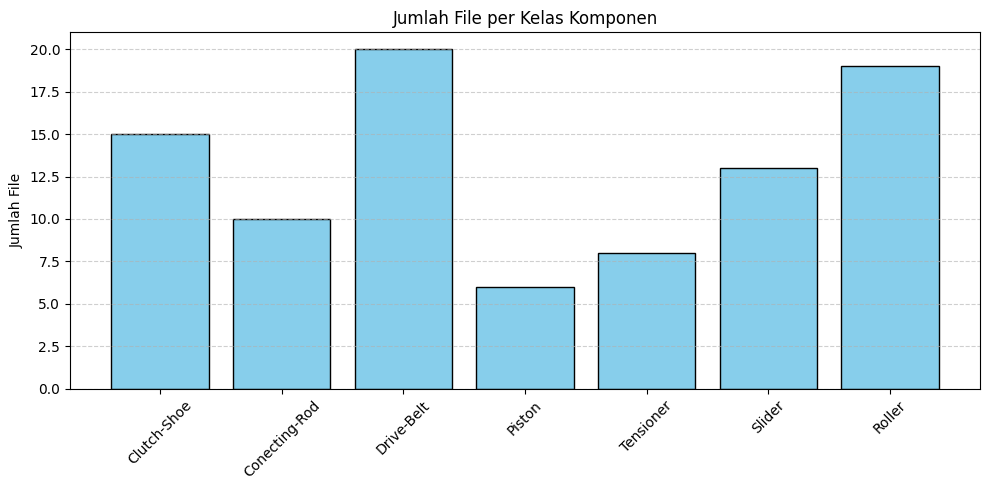

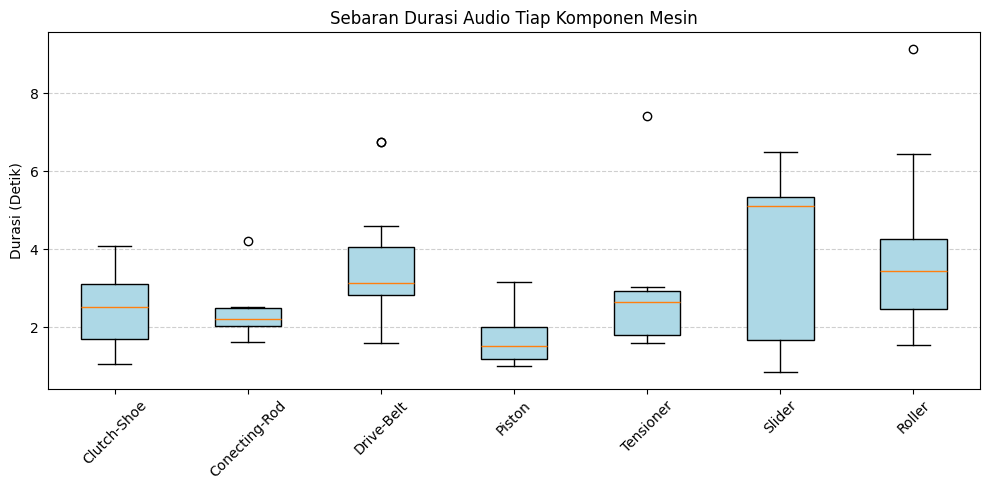

In [ ]:
durasi_dict = {}
jumlah_file_dict = {}


for cls in classes:
    path = os.path.join(base_dir, cls)
    if not os.path.exists(path):
        continue
        
    files = [f for f in os.listdir(path) if f.endswith(('.wav', '.mp3'))]
    durasi_list = [librosa.get_duration(path=os.path.join(path, f)) for f in files]
    
    if durasi_list:
        durasi_dict[cls] = durasi_list
        jumlah_file_dict[cls] = len(files)
        # print(f"{cls:<15} | {len(files):<5} | {np.mean(durasi_list):<8.2f}s | {np.min(durasi_list):<4.2f}s | {np.max(durasi_list):<4.2f}s")

# --- Visualisasi 1: Persebaran Jumlah File per Kelas (Bar Chart) ---
plt.figure(figsize=(10, 5))
plt.bar(jumlah_file_dict.keys(), jumlah_file_dict.values(), color='skyblue', edgecolor='black')
plt.title("Jumlah File per Kelas Komponen")
plt.ylabel("Jumlah File")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Visualisasi 2: Sebaran Durasi Audio (Boxplot Asli) ---
plt.figure(figsize=(10, 5))
plt.boxplot(durasi_dict.values(), tick_labels=durasi_dict.keys(), patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title("Sebaran Durasi Audio Tiap Komponen Mesin")
plt.ylabel("Durasi (Detik)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Kelas

In [18]:
import os
import librosa

base_dir = "Dataset-Part-Rusak"
classes = ["Clutch-Shoe", "Conecting-Rod", "Drive-Belt", "Piston", "Tensioner", "Slider", "Roller"]

for cls in classes:
    path = os.path.join(base_dir, cls)
    if not os.path.exists(path):
        continue
        
    print(f"\n--- Kelas: {cls} ---")
    
    # Ambil list file dan urutkan sesuai abjad
    files = sorted([f for f in os.listdir(path) if f.endswith(('.wav', '.mp3', '.m4a'))])
    
    for f in files:
        file_path = os.path.join(path, f)
        durasi = librosa.get_duration(path=file_path)
        
        # Hilangkan ekstensi file (misal .wav) untuk nama output
        nama_file = os.path.splitext(f)[0]
        
        # Format output waktu
        if durasi >= 60:
            menit = int(durasi // 60)
            detik = int(durasi % 60)
            print(f"{nama_file} {menit} menit {detik} detik")
        else:
            print(f"{nama_file} {durasi:.2f} detik")


--- Kelas: Clutch-Shoe ---
Clutch-Shoe-1 2.51 detik
Clutch-Shoe-13 3.61 detik
Clutch-Shoe-14 1.93 detik
Clutch-Shoe-16 2.33 detik
Clutch-Shoe-17 2.92 detik
Clutch-Shoe-2 1.48 detik
Clutch-Shoe-20 2.67 detik
Clutch-Shoe-23 2.17 detik
Clutch-Shoe-25 3.12 detik
Clutch-Shoe-27 4.05 detik
Clutch-Shoe-28 1.40 detik
Clutch-Shoe-29 1.21 detik
Clutch-Shoe-32 1.07 detik
Clutch-Shoe-33 3.11 detik
Clutch-Shoe-37 4.08 detik

--- Kelas: Conecting-Rod ---
Conecting-Road-1 1.99 detik
Conecting-Road-13 2.39 detik
Conecting-Road-14 2.15 detik
Conecting-Road-15 2.12 detik
Conecting-Road-17 2.52 detik
Conecting-Road-20 1.62 detik
Conecting-Road-23 1.83 detik
Conecting-Road-33 2.52 detik
Conecting-Road-4 4.21 detik
Conecting-Road-5 2.29 detik

--- Kelas: Drive-Belt ---
Drive-Belt-1 2.30 detik
Drive-Belt-12 1.60 detik
Drive-Belt-13 3.28 detik
Drive-Belt-14 3.05 detik
Drive-Belt-16 2.88 detik
Drive-Belt-19 6.74 detik
Drive-Belt-2 4.40 detik
Drive-Belt-20 2.15 detik
Drive-Belt-21 3.08 detik
Drive-Belt-24 3.0

# Data Preprocessing

### Sorting 

In [ ]:
base_dir = "Dataset-Part-Rusak"
classes = ["Clutch-Shoe", "Conecting-Rod", "Drive-Belt", "Piston", "Tensioner", "Slider", "Roller"]
out_dir = "Dataset-Renamed"
os.makedirs(out_dir, exist_ok=True)

print("rename file...\n")

for cls in classes:
    in_path = os.path.join(base_dir, cls)
    out_path = os.path.join(out_dir, cls)
    
    if not os.path.exists(in_path):
        continue
        
    os.makedirs(out_path, exist_ok=True)
    
    # Ambil file dan urutkan berdasarkan nama aslinya
    files = sorted([f for f in os.listdir(in_path) if f.endswith(('.wav', '.mp3', '.m4a'))])
    
    for i, f in enumerate(files, start=1):
        ext = os.path.splitext(f)[1] # Ambil ekstensi asli
        
        # Format nama baru: kelas-001.wav
        nama_baru = f"{cls.lower()}-{i:03d}{ext}"
        
        path_lama = os.path.join(in_path, f)
        path_baru = os.path.join(out_path, nama_baru)
        
        # Salin file ke folder baru dengan nama baru
        shutil.copy(path_lama, path_baru)
        
print(f"Selesai!")

rename file...

Selesai!


### Menyeragamkan durasi

In [32]:

base_dir = "Dataset-Renamed"
out_dir = "Dataset-Duration"
classes = ["Clutch-Shoe", "Conecting-Rod", "Drive-Belt", "Piston", "Tensioner", "Slider", "Roller"]

os.makedirs(out_dir, exist_ok=True)
target_len = 16000 * 2  

print("Memulai proses preprocessing (Standarisasi 3 Detik)...\n")
print(f"{'KELAS':<15} | {'SEBELUM':<10} | {'SESUDAH':<10}")
print("-" * 43)

for cls in classes:
    in_path = os.path.join(base_dir, cls)
    out_path = os.path.join(out_dir, cls)
    
    if not os.path.exists(in_path): 
        continue
        
    os.makedirs(out_path, exist_ok=True)
    files = [f for f in os.listdir(in_path) if f.endswith(('.wav', '.mp3', '.m4a'))]
    
    jml_sebelum = len(files)
    
    for f in files:
        audio, sr = librosa.load(os.path.join(in_path, f), sr=16000)
        nama_asli = os.path.splitext(f)[0]
        
        if len(audio) < target_len:
            audio_pad = np.pad(audio, (0, target_len - len(audio)))
            sf.write(os.path.join(out_path, f"{nama_asli}_pad.wav"), audio_pad, sr)
        else:
            jumlah_chunk = len(audio) // target_len
            for i in range(jumlah_chunk):
                start = i * target_len
                end = start + target_len
                chunk = audio[start:end]
                sf.write(os.path.join(out_path, f"{nama_asli}_part{i+1}.wav"), chunk, sr)

    # Hitung jumlah file baru setelah dipecah/di-padding
    jml_sesudah = len(os.listdir(out_path))
    
    # Cetak ke layar
    print(f"{cls:<15} | {jml_sebelum:<10} | {jml_sesudah:<10}")

print("\nSelesai")

Memulai proses preprocessing (Standarisasi 3 Detik)...

KELAS           | SEBELUM    | SESUDAH   
-------------------------------------------
Clutch-Shoe     | 15         | 17        
Conecting-Rod   | 10         | 11        
Drive-Belt      | 20         | 29        
Piston          | 6          | 6         
Tensioner       | 8          | 10        
Slider          | 13         | 22        
Roller          | 19         | 29        

Selesai
